### Importar as bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

### Carregar os dados

In [2]:
df = pd.read_csv('../dataset/limpo.csv')

### Resumo dos números

O resumo mostra contagem, média, variação e limites das colunas numéricas.

In [3]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.503000e+03,4503.000000,4503.000000,4503.000000,4.503000e+03,4503.000000,4503.000000,4503.000000,4503.000000,4503.000000,4503.000000,4503.000000,4503.000000,4503.000000
mean,5.284046e+05,3.386187,2.139352,2102.002443,1.473259e+04,1.508550,0.004886,0.220076,3.448812,1799.607373,302.395070,1970.784588,808.321341,259.393800
std,2.905777e+05,0.895646,0.747635,884.772932,3.583187e+04,0.537451,0.069734,0.737536,0.673802,813.921776,444.856323,29.721247,979.372664,103.615655
min,7.800000e+03,1.000000,0.750000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,10.000000
25%,3.250000e+05,3.000000,1.750000,1460.000000,5.000000e+03,1.000000,0.000000,0.000000,3.000000,1180.000000,0.000000,1951.000000,0.000000,182.155000
50%,4.610000e+05,3.000000,2.250000,1960.000000,7.642000e+03,1.500000,0.000000,0.000000,3.000000,1580.000000,0.000000,1976.000000,0.000000,243.950000
75%,6.500000e+05,4.000000,2.500000,2590.000000,1.085900e+04,2.000000,0.000000,0.000000,4.000000,2275.000000,600.000000,1997.000000,1999.000000,313.780000
max,2.005000e+06,9.000000,5.750000,7320.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,7320.000000,2850.000000,2014.000000,2014.000000,769.230000


### Distribuição dos preços

O histograma mostra as faixas de preço mais comuns na base tratada.

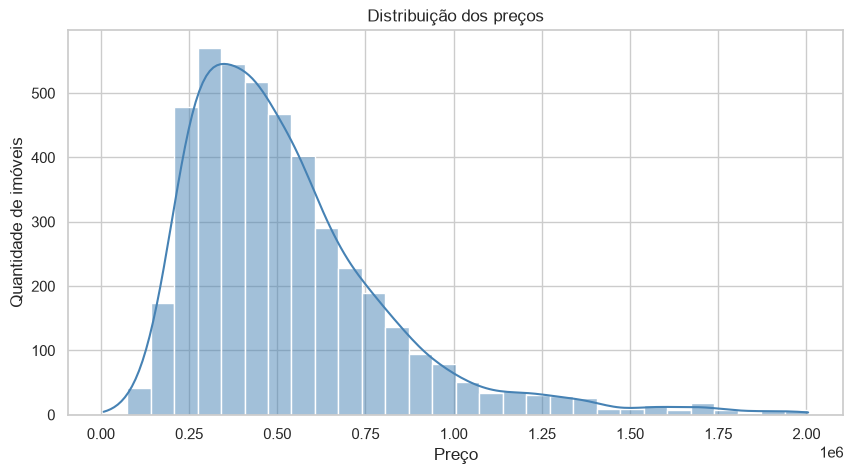

In [4]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='price', bins=30, kde=True, color='steelblue')
plt.title('Distribuição dos preços')
plt.xlabel('Preço')
plt.ylabel('Quantidade de imóveis')
plt.show()

### Preço e área habitável

Cada ponto é um imóvel e ajuda a observar se áreas maiores costumam custar mais.

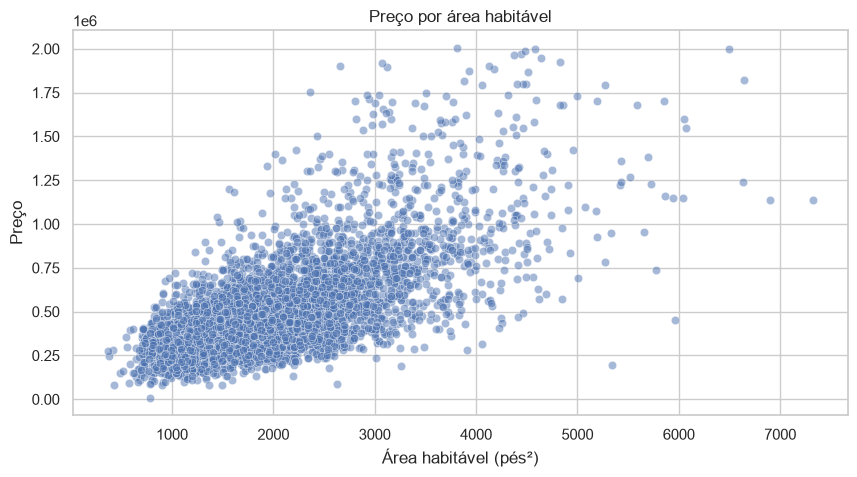

In [5]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='sqft_living', y='price', alpha=0.5)
plt.title('Preço por área habitável')
plt.xlabel('Área habitável (pés²)')
plt.ylabel('Preço')
plt.show()

### Cidades com mais imóveis

O gráfico apresenta as 10 cidades com mais registros na base.

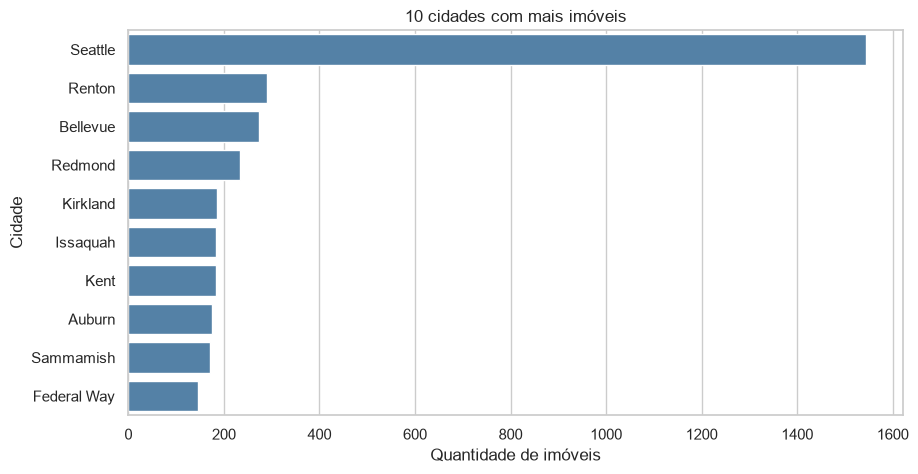

In [6]:
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    y='city',
    order=df['city'].value_counts().head(10).index,
    color='steelblue'
)
plt.title('10 cidades com mais imóveis')
plt.xlabel('Quantidade de imóveis')
plt.ylabel('Cidade')
plt.show()

### Preço médio por cidade

Agrupamos os imóveis para comparar as 10 maiores médias de preço.

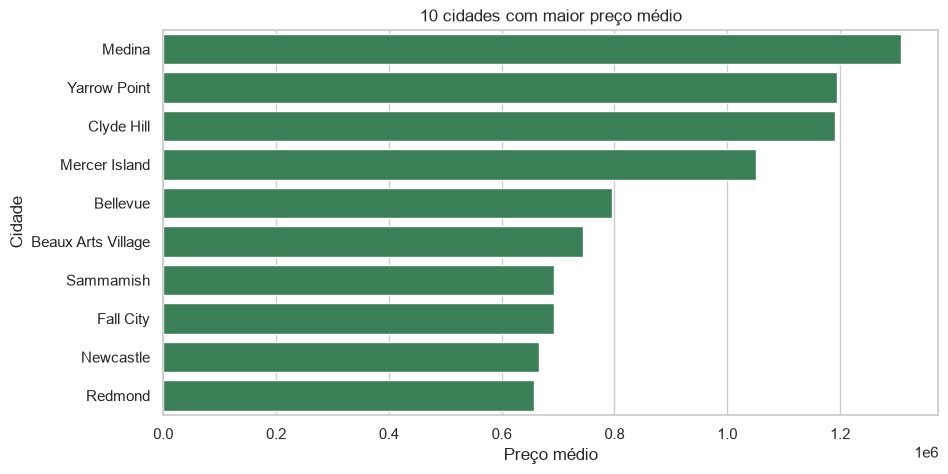

In [7]:
preco_medio_cidade = df.groupby('city')['price'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=preco_medio_cidade.values, y=preco_medio_cidade.index, color='seagreen')
plt.title('10 cidades com maior preço médio')
plt.xlabel('Preço médio')
plt.ylabel('Cidade')
plt.show()

### Preço e localização à beira d'água

O boxplot compara os preços dos imóveis sem e com localização à beira d'água.

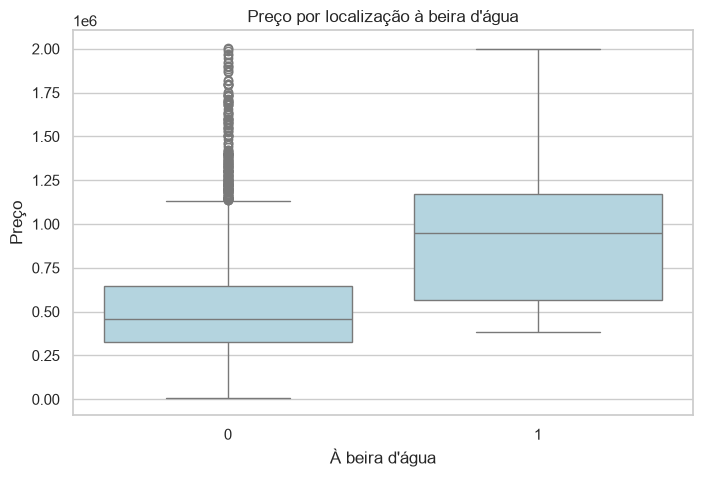

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='waterfront', y='price', color='lightblue')
plt.title("Preço por localização à beira d'água")
plt.xlabel("À beira d'água")
plt.ylabel('Preço')
plt.show()

### Correlação entre variáveis

Valores próximos de 1 ou -1 indicam relações lineares mais fortes.

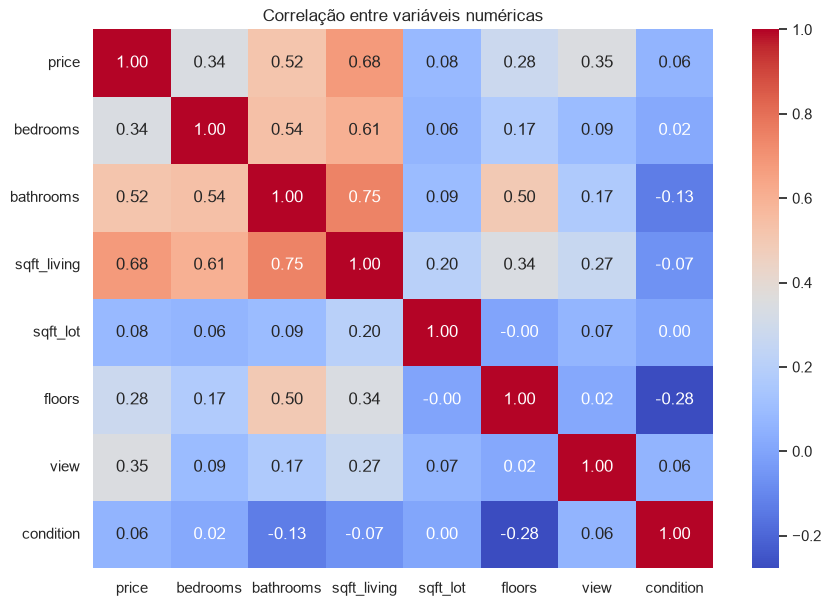

In [9]:
plt.figure(figsize=(10, 7))
sns.heatmap(
    df[['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'view', 'condition']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlação entre variáveis numéricas')
plt.show()

### Conclusão

Os gráficos destacam como preço, tamanho e localização se relacionam na base.